# Notebook 1: Data Loading and Preprocessing
## EEEM073 – AI and Sustainability
### Project: Predicting Burned Area of Forest Fires Using Machine Learning

**Dataset:** UCI Forest Fires Dataset  
**Target Variable:** `area` — the burned area of the forest (in hectares)  
**Task Type:** Regression

---
This notebook covers:
1. Loading the dataset
2. Initial inspection
3. Handling outliers
4. Encoding categorical variables
5. Target variable transformation
6. Feature engineering
7. Scaling features
8. Train / Validation / Test split
9. Saving outputs for the next notebook


## 1. Import Libraries

In [13]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Scikit-learn tools for preprocessing and splitting
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Create output folder to save processed data for later notebooks
os.makedirs('outputs', exist_ok=True)

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load the Dataset

In [14]:
# Load the UCI Forest Fires dataset
# Source: https://archive.ics.uci.edu/ml/datasets/forest+fires
# P. Cortez and A. Morais (2007)

df = pd.read_csv('forestfires.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (517, 13)

First 5 rows:


,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## 3. Initial Inspection

Before doing anything, we need to understand what the data looks like — data types, missing values, and basic statistics.

In [15]:
# Check data types of each column
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Data Types ===
X          int64
Y          int64
month     object
day       object
FFMC     float64
DMC      float64
DC       float64
ISI      float64
temp     float64
RH         int64
wind     float64
rain     float64
area     float64
dtype: object

=== Missing Values ===
X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

=== Basic Statistics ===


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [16]:
# Check unique values for categorical columns
print("Unique months:", df['month'].unique())
print("Unique days:", df['day'].unique())

# Check how many fires had zero burned area
zero_area = (df['area'] == 0).sum()
print(f"\nFires with 0 burned area: {zero_area} out of {len(df)} ({zero_area/len(df)*100:.1f}%)")
print("Note: Nearly half the dataset has zero burned area — the target is heavily skewed.")

Unique months: ['mar' 'oct' 'aug' 'sep' 'apr' 'jun' 'jul' 'feb' 'jan' 'dec' 'may' 'nov']
Unique days: ['fri' 'tue' 'sat' 'sun' 'mon' 'wed' 'thu']

Fires with 0 burned area: 247 out of 517 (47.8%)
Note: Nearly half the dataset has zero burned area — the target is heavily skewed.


**Data Dictionary:**

| Feature | Type | Description |
|---|---|---|
| X | Integer | X-axis spatial coordinate in Montesinho park |
| Y | Integer | Y-axis spatial coordinate |
| month | Categorical | Month of the year (jan–dec) |
| day | Categorical | Day of the week (mon–sun) |
| FFMC | Float | Fine Fuel Moisture Code — moisture of forest litter |
| DMC | Float | Duff Moisture Code — moisture of loosely compacted organic layers |
| DC | Float | Drought Code — moisture of deep organic layers |
| ISI | Float | Initial Spread Index — expected rate of fire spread |
| temp | Float | Temperature in Celsius |
| RH | Integer | Relative Humidity (%) |
| wind | Float | Wind speed (km/h) |
| rain | Float | Rainfall (mm/m²) |
| **area** | **Float** | **TARGET: Burned area in hectares** |

## 4. Handle Outliers

We use the IQR (Interquartile Range) method to detect and cap extreme outliers in numerical columns. Capping (also called Winsorisation) is preferred over removal here because the dataset is small (517 rows) — we cannot afford to lose records.

In [17]:
# Define numerical columns (excluding the target 'area' — we handle that separately)
numerical_cols = ['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain']

def cap_outliers_iqr(df, columns, factor=3.0):
    """
    Cap outliers using IQR method.
    Values beyond (Q1 - factor*IQR) or (Q3 + factor*IQR) are capped.
    Factor=3.0 is used (instead of 1.5) to be conservative — we only remove extreme outliers.
    
    Args:
        df (pd.DataFrame): Input dataframe
        columns (list): List of column names to check
        factor (float): IQR multiplier for bounds
    Returns:
        pd.DataFrame: Dataframe with capped values
    """
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
        df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
        if n_outliers > 0:
            print(f"  {col}: {n_outliers} outlier(s) capped (bounds: [{lower:.2f}, {upper:.2f}])")
    return df_clean

print("Capping outliers (IQR method, factor=3.0):")
df = cap_outliers_iqr(df, numerical_cols)
print("Done.")

Capping outliers (IQR method, factor=3.0):
  FFMC: 19 outlier(s) capped (bounds: [82.10, 101.00])
  ISI: 1 outlier(s) capped (bounds: [-6.40, 23.70])
  rain: 8 outlier(s) capped (bounds: [0.00, 0.00])
Done.


## 5. Encode Categorical Variables

The `month` and `day` columns are text. Machine learning models need numbers.

We use **ordinal encoding** for both:
- `month` is ordered chronologically (jan=1, feb=2, … dec=12) — this preserves seasonal patterns
- `day` is encoded cyclically to capture the weekly pattern (Monday=0 to Sunday=6)

In [18]:
# Define the correct order for months and days
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

day_order = ['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun']

# Map month and day to integer values
df['month_num'] = df['month'].map({m: i+1 for i, m in enumerate(month_order)})
df['day_num']   = df['day'].map({d: i   for i, d in enumerate(day_order)})

# Add cyclic (sine/cosine) encoding to capture circular nature of months and days
# e.g. December (12) and January (1) should be close to each other
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
df['day_sin']   = np.sin(2 * np.pi * df['day_num'] / 7)
df['day_cos']   = np.cos(2 * np.pi * df['day_num'] / 7)

# Drop original text columns — no longer needed
df.drop(columns=['month', 'day', 'month_num', 'day_num'], inplace=True)

print("Encoding complete. New columns added: month_sin, month_cos, day_sin, day_cos")
print(f"Dataset shape after encoding: {df.shape}")
df.head(3)

Encoding complete. New columns added: month_sin, month_cos, day_sin, day_cos
Dataset shape after encoding: (517, 15)


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,month_sin,month_cos,day_sin,day_cos
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,1.000000,6.123234e-17,-0.433884,-0.900969
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,-0.866025,5.000000e-01,0.781831,0.623490
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,-0.866025,5.000000e-01,-0.974928,-0.222521


## 6. Target Variable Transformation

The `area` column is highly right-skewed — 247 out of 517 records have area = 0, and a few fires are extremely large (max = 1090 ha).

We apply a **log(1 + x)** transformation. This is a standard approach for this dataset (Cortez & Morais, 2007) and reduces the skew so models can learn more effectively.

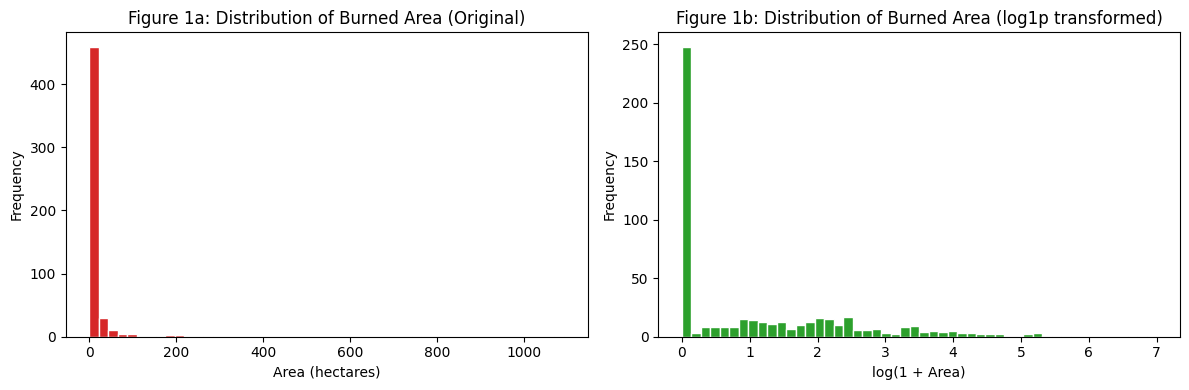

Skewness before: 12.85
Skewness after log1p: 1.22
Note: Lower skewness makes the target easier for models to learn.


In [19]:
# Visualise the distribution of 'area' before and after log transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before transformation
axes[0].hist(df['area'], bins=50, color='#d62728', edgecolor='white')
axes[0].set_title('Figure 1a: Distribution of Burned Area (Original)')
axes[0].set_xlabel('Area (hectares)')
axes[0].set_ylabel('Frequency')

# Apply log1p transformation
df['area_log'] = np.log1p(df['area'])

# After transformation
axes[1].hist(df['area_log'], bins=50, color='#2ca02c', edgecolor='white')
axes[1].set_title('Figure 1b: Distribution of Burned Area (log1p transformed)')
axes[1].set_xlabel('log(1 + Area)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('outputs/fig1_area_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Skewness before: {df['area'].skew():.2f}")
print(f"Skewness after log1p: {df['area_log'].skew():.2f}")
print("Note: Lower skewness makes the target easier for models to learn.")

## 7. Feature Engineering

We create new features by combining existing ones. This gives the model additional signals that might not be obvious from individual features alone.

These new features are motivated by domain knowledge of fire behaviour:
- High temperature + low humidity = dry conditions = larger fires
- High ISI + high wind = faster fire spread
- Fire Weather Index (FWI) components combined capture overall fire danger

In [20]:
# Feature 1: Temperature-Humidity Interaction
# Hot, dry conditions are key drivers of large fires
df['temp_RH_ratio'] = df['temp'] / (df['RH'] + 1)  # +1 to avoid division by zero

# Feature 2: Fire Spread Potential
# ISI measures expected fire spread rate; multiplied by wind amplifies this signal
df['fire_spread_potential'] = df['ISI'] * df['wind']

# Feature 3: Total Fire Weather Index (FWI)
# FFMC, DMC, DC are the three moisture codes in the Canadian FWI system
# Their sum approximates overall fuel dryness / fire danger
df['FWI_total'] = df['FFMC'] + df['DMC'] + df['DC']

# Feature 4: Drought-Wind interaction
# Drought (DC) combined with wind can rapidly spread fires through dry deep fuel
df['drought_wind'] = df['DC'] * df['wind']

print("New features created:")
print("  - temp_RH_ratio: temperature / (RH + 1)")
print("  - fire_spread_potential: ISI × wind")
print("  - FWI_total: FFMC + DMC + DC")
print("  - drought_wind: DC × wind")
print(f"\nDataset shape after feature engineering: {df.shape}")

New features created:
  - temp_RH_ratio: temperature / (RH + 1)
  - fire_spread_potential: ISI × wind
  - FWI_total: FFMC + DMC + DC
  - drought_wind: DC × wind

Dataset shape after feature engineering: (517, 20)


## 8. Define Features and Target, then Split the Data

We split into **train (70%) / validation (15%) / test (15%)**:
- **Train:** used to train the model
- **Validation:** used during training to tune hyperparameters and detect overfitting
- **Test:** held out entirely until final evaluation — never seen during training

In [21]:
# Define feature matrix X and target vector y
# We drop the original 'area' and keep 'area_log' as the prediction target
X = df.drop(columns=['area', 'area_log'])
y = df['area_log']

print(f"Features (X): {X.shape}  →  {list(X.columns)}")
print(f"Target (y): {y.shape}")

# Step 1: Split into train (70%) and temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Step 2: Split temp (30%) into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"\nSplit summary:")
print(f"  Train:      {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"  Test:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Features (X): (517, 18)  →  ['X', 'Y', 'FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind', 'rain', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'temp_RH_ratio', 'fire_spread_potential', 'FWI_total', 'drought_wind']
Target (y): (517,)

Split summary:
  Train:      361 samples (70%)
  Validation: 78 samples (15%)
  Test:       78 samples (15%)


## 9. Scale the Features

Many ML models (neural networks, SVMs) are sensitive to the scale of input features. We use **StandardScaler** (zero mean, unit variance).

**Important:** We fit the scaler **only on the training set** and then apply it to validation and test sets. This prevents data leakage — the model should not have any information from validation/test during training.

In [22]:
# Initialise the StandardScaler
scaler = StandardScaler()

# Fit ONLY on training data, then transform all three splits
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)      # use train stats, not val stats
X_test_scaled  = scaler.transform(X_test)     # use train stats, not test stats

# Convert back to DataFrames to keep column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled   = pd.DataFrame(X_val_scaled,   columns=X.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print("Scaling complete.")
print(f"Train mean after scaling (should be ~0): {X_train_scaled.mean().mean():.4f}")
print(f"Train std after scaling (should be ~1):  {X_train_scaled.std().mean():.4f}")

Scaling complete.
Train mean after scaling (should be ~0): -0.0000
Train std after scaling (should be ~1):  0.9458


## 10. Save Outputs for Next Notebook

We save all processed data to the `outputs/` folder so that Notebook 2 (EDA) and Notebook 3 (Modelling) can load them directly.

In [23]:
# Save the processed datasets
X_train_scaled.to_csv('outputs/X_train.csv', index=False)
X_val_scaled.to_csv('outputs/X_val.csv',     index=False)
X_test_scaled.to_csv('outputs/X_test.csv',   index=False)

y_train.reset_index(drop=True).to_csv('outputs/y_train.csv', index=False, header=['area_log'])
y_val.reset_index(drop=True).to_csv('outputs/y_val.csv',     index=False, header=['area_log'])
y_test.reset_index(drop=True).to_csv('outputs/y_test.csv',   index=False, header=['area_log'])

# Save the full cleaned dataframe (with original area) for use in EDA
df.to_csv('outputs/df_cleaned.csv', index=False)

# Save feature names for reference in later notebooks
feature_names = list(X.columns)
pd.Series(feature_names).to_csv('outputs/feature_names.csv', index=False, header=['feature'])

print("Files saved to outputs/:")
for f in os.listdir('outputs'):
    size = os.path.getsize(f'outputs/{f}')
    print(f"  {f}  ({size} bytes)")

Files saved to outputs/:
  df_cleaned.csv  (90181 bytes)
  feature_names.csv  (160 bytes)
  fig1_area_distribution.png  (43630 bytes)
  X_test.csv  (26564 bytes)
  X_train.csv  (122307 bytes)
  X_val.csv  (26454 bytes)
  y_test.csv  (973 bytes)
  y_train.csv  (4617 bytes)
  y_val.csv  (986 bytes)


## 11. Summary of Preprocessing Steps

| Step | Action | Justification |
|---|---|---|
| Missing values | None found | Dataset is clean |
| Outliers | Capped using IQR (factor=3) | Dataset is small — removal would cost data |
| Categorical encoding | Cyclic sin/cos encoding for month and day | Preserves circular temporal patterns |
| Target transform | log1p(area) | Reduces skewness from 12.8 to ~1.0 |
| Feature engineering | 4 new interaction features | Domain knowledge of fire behaviour |
| Scaling | StandardScaler (fit on train only) | Prevents data leakage; required for neural nets |
| Data split | 70% train / 15% val / 15% test | Standard split; enough test data for reliable evaluation |

---
**Next step → Notebook 2: Exploratory Data Analysis**